# Bitcoin Market Regime Detection using Machine Learning

## Motivation

Financial markets are non-stationary and exhibit different regimes over time.
Bitcoin, in particular, is known for its extreme volatility and speculative cycles.

In this notebook, we use unsupervised machine learning techniques to identify
hidden market regimes in Bitcoin price data.

## Objective

- Detect market regimes (bull, bear, high volatility)
- Use feature engineering to capture market dynamics
- Apply clustering techniques to identify patterns
- Evaluate whether regimes can be used for trading strategies

## Imports

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Data Download

In [3]:
# Download Bitcoin data (auto_adjust=True avoids Adj Close issues)
btc = yf.download("BTC-USD", start="2015-01-01", auto_adjust=True)

# Keep relevant columns
btc = btc[['Close', 'Volume']]

# Rename for clarity
btc.columns = ['price', 'volume']

# Optional: ensure no MultiIndex (robustness)
if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.droplevel(1)

btc.head()

[*********************100%***********************]  1 of 1 completed


,price,volume
Date,,
2015-01-01,314.248993,8036550
2015-01-02,315.032013,7860650
2015-01-03,281.082001,33054400
2015-01-04,264.195007,55629100
2015-01-05,274.473999,43962800


### Data Overview

The dataset contains daily Bitcoin price and trading volume starting from 2015.

- **Price** represents the adjusted closing price (auto-adjusted by Yahoo Finance)
- **Volume** represents the total traded volume per day

The data appears consistent with historical Bitcoin price levels,
starting around $300 in early 2015.

This dataset will be used to extract features that capture market behavior,
including returns, volatility, momentum, and drawdowns.

### Data Quality Notes

Yahoo Finance recently updated its API to return auto-adjusted prices by default.
Therefore, the 'Close' column already reflects adjusted values and no separate
'Adj Close' column is required.

This ensures consistency in return calculations and avoids common data issues.

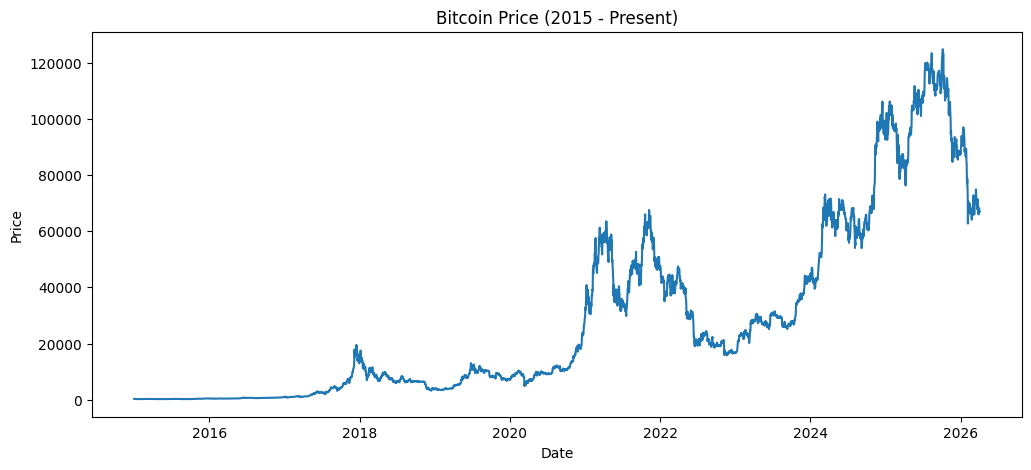

In [4]:
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc['price'])
plt.title("Bitcoin Price (2015 - Present)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Price Evolution

Bitcoin exhibits strong non-linear behavior, characterized by:

- Rapid bull runs (e.g., 2017, 2021)
- Deep drawdowns (bear markets)
- Periods of consolidation

This non-stationary behavior motivates the use of machine learning
to identify underlying market regimes.

## Feature Enginneering

In [5]:
# Log returns
btc['returns'] = np.log(btc['price'] / btc['price'].shift(1))

# Rolling volatility (14 days)
btc['volatility'] = btc['returns'].rolling(14).std()

# Momentum (14 days)
btc['momentum'] = btc['price'].pct_change(14)

# Drawdown
btc['cum_max'] = btc['price'].cummax()
btc['drawdown'] = (btc['price'] - btc['cum_max']) / btc['cum_max']

# Volume change
btc['vol_change'] = btc['volume'].pct_change()

# Drop NaNs
btc = btc.dropna()

btc.head()

,price,volume,returns,volatility,momentum,cum_max,drawdown,vol_change
Date,,,,,,,,
2015-01-15,209.843994,81773504,0.164002,0.099166,-0.332237,315.032013,-0.333896,-0.162489
2015-01-16,208.097000,38421000,-0.008360,0.098944,-0.339442,315.032013,-0.339442,-0.530153
2015-01-17,199.259995,23469700,-0.043394,0.096068,-0.291097,315.032013,-0.367493,-0.389144
2015-01-18,210.339005,30085100,0.054110,0.097590,-0.203849,315.032013,-0.332325,0.281870
2015-01-19,214.860992,18658300,0.021271,0.096967,-0.217190,315.032013,-0.317971,-0.379816


### Feature Engineering

To capture the dynamics of Bitcoin's price behavior, we construct several key features:

- **Log Returns**: Measure daily price changes in a statistically consistent way
- **Volatility**: Rolling standard deviation of returns (14-day window)
- **Momentum**: Percentage change over a 14-day period
- **Drawdown**: Distance from the historical peak price
- **Volume Change**: Daily percentage change in trading volume

These features are designed to capture different aspects of market behavior:
trend, risk, and market stress.

### Feature Interpretation

The initial observations already reveal important characteristics of Bitcoin:

- The dataset starts during a significant **bear market**, with drawdowns exceeding -30%
- Volatility remains elevated, reflecting the inherently unstable nature of crypto markets
- Momentum is negative, confirming a downward trend during this period
- Large fluctuations in volume suggest periods of panic selling and market uncertainty

These patterns highlight why traditional linear models may struggle,
and motivate the use of unsupervised learning to detect hidden regimes.

### Why These Features Matter

Each feature plays a specific role in identifying market regimes:

- **Returns + Momentum** → Trend detection
- **Volatility** → Risk and uncertainty
- **Drawdown** → Market stress and crash identification
- **Volume Change** → Market participation and sentiment

By combining these variables, we create a multi-dimensional representation
of the market state, suitable for clustering algorithms.

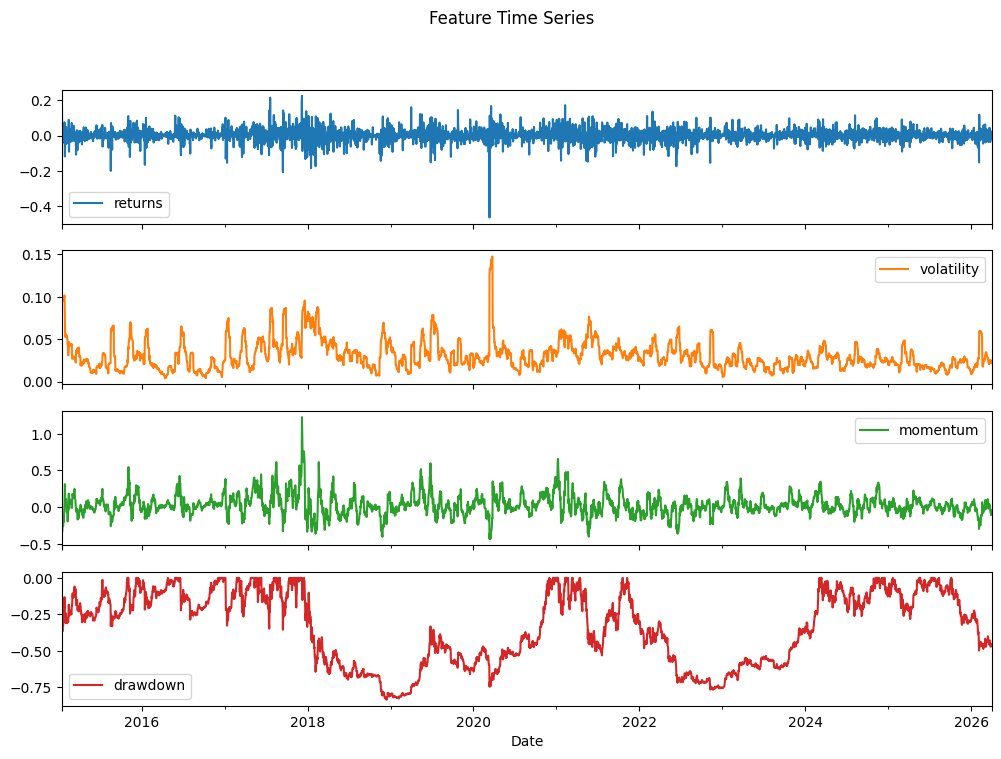

In [6]:
btc[['returns', 'volatility', 'momentum', 'drawdown']].plot(
    subplots=True,
    figsize=(12,8),
    title="Feature Time Series"
)
plt.show()

### Feature Dynamics

The time series of engineered features show clear regime shifts over time:

- Volatility spikes during crisis periods
- Drawdowns deepen during bear markets
- Momentum alternates between positive and negative phases

These non-linear patterns suggest the presence of distinct market regimes.

## Prepare Features

In [7]:
features = btc[['returns', 'volatility', 'momentum', 'drawdown', 'vol_change']]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## Clustering Model (K-Means)

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

btc['regime'] = kmeans.fit_predict(X_scaled)

In [13]:
regime_order = btc.groupby('regime')['returns'].mean().sort_values().index
mapping = {old: new for new, old in enumerate(regime_order)}
btc['regime_ordered'] = btc['regime'].map(mapping)

### Ordered Regime Representation

To improve interpretability, regimes were reordered based on their average returns.

This transformation assigns a natural ordering:

- Lower values → lower average returns (bearish regimes)
- Higher values → higher average returns (bullish regimes)

This allows for a more intuitive understanding of market states.

## Visualization

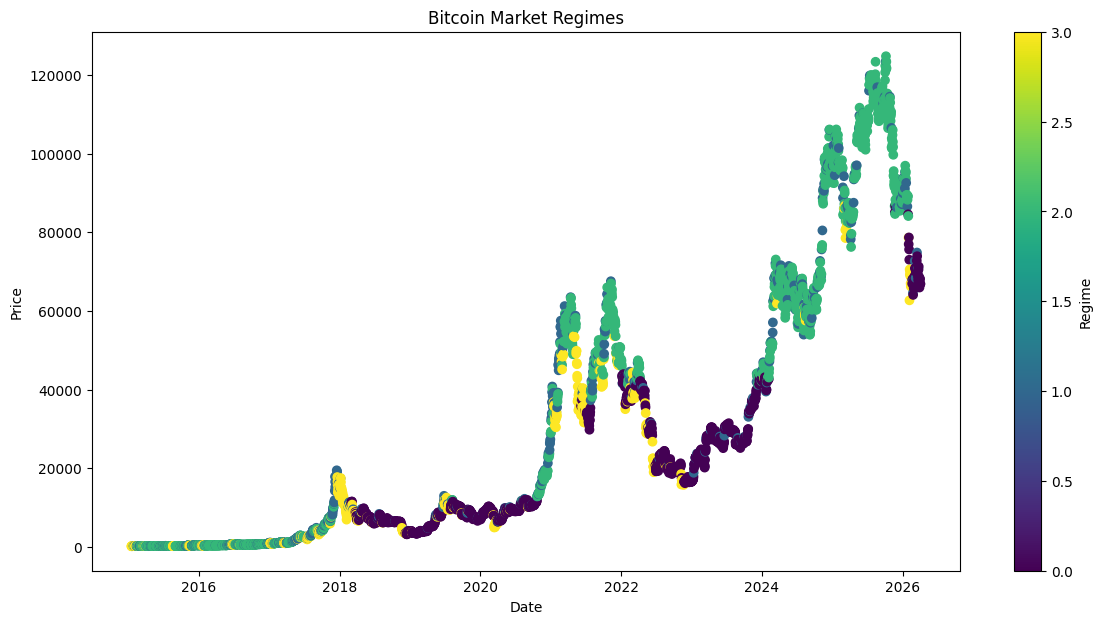

In [14]:
plt.figure(figsize=(14,7))

scatter = plt.scatter(
    btc.index,
    btc['price'],
    c=btc['regime']
)

plt.title("Bitcoin Market Regimes")
plt.xlabel("Date")
plt.ylabel("Price")
plt.colorbar(scatter, label='Regime')

plt.show()

### Regime Interpretation

After ordering the regimes by average returns, we can interpret them as follows:

- **Regime 0 (Lowest returns)**:
  Deep bear markets, characterized by strong negative returns and large drawdowns

- **Regime 1**:
  Weak or unstable market conditions, often during transitions or consolidation phases

- **Regime 2**:
  Positive momentum with moderate volatility, typical of early or sustained bull phases

- **Regime 3 (Highest returns)**:
  Strong bull markets with high momentum and increasing participation

### Key Insight

The ordered regimes reveal a clear market structure:

- Bitcoin cycles through distinct phases rather than moving randomly
- Extreme regimes (0 and 3) correspond to crisis and euphoria
- Intermediate regimes (1 and 2) capture transitions between these extremes

This structure suggests that regime transitions could be used
as signals for dynamic portfolio allocation.

### Regime Transitions

One notable observation is that transitions between regimes are not instantaneous:

- Markets often move gradually from bearish to bullish states
- High-volatility regimes tend to appear during transitions
- This indicates that regime shifts may be predictable to some extent

This opens the door to predictive modeling of regime changes.

## Regime Analysis

In [15]:
btc.groupby('regime_ordered')[
    ['returns', 'volatility', 'momentum', 'drawdown']
].mean()

,returns,volatility,momentum,drawdown
regime_ordered,,,,
0,-0.025673,0.059878,-0.114413,-0.397387
1,-0.000885,0.024160,0.039758,-0.136887
2,-0.000284,0.025882,0.009807,-0.593645
3,0.037105,0.035486,0.174808,-0.182413


### Quantitative Regime Interpretation

By analyzing the average feature values for each regime, we can assign
clear economic meaning to the clusters:

- **Regime 0 — Crash / Panic Phase**
  - Strongly negative returns (-2.56%)
  - High drawdowns (~ -40%)
  - Negative momentum
  → Represents capitulation and panic selling events

- **Regime 1 — Recovery / Accumulation**
  - Near-zero returns
  - Positive momentum
  - Lower volatility
  → Indicates early recovery and accumulation phases

- **Regime 2 — Depressed / Post-Crash Consolidation**
  - Near-zero returns
  - Extremely deep drawdowns (~ -59%)
  - Weak momentum
  → Suggests prolonged periods of market weakness after major crashes

- **Regime 3 — Bull Market / Expansion**
  - Strong positive returns (+3.7%)
  - High momentum
  - Moderate volatility
  → Represents strong upward trends and market expansion

### Key Insight

Not all low-return environments are equal.

Regime 1 and Regime 2 both exhibit near-zero returns,
but differ significantly in drawdown:

- Regime 1 → recovery phase
- Regime 2 → deeply depressed market conditions

This distinction is critical for portfolio allocation and risk management.

### Trading Implications

- Avoid exposure during **Regime 0 (crash phase)**
- Accumulate during **Regime 1 (recovery phase)**
- Be cautious in **Regime 2 (post-crash stagnation)**
- Increase exposure during **Regime 3 (bull phase)**

This suggests that regime-based strategies could improve
risk-adjusted returns in highly volatile assets like Bitcoin.

### Final Takeaway

This analysis demonstrates that Bitcoin's market structure is not random.

Instead, it evolves through distinct and economically meaningful regimes,
which can be detected using unsupervised machine learning.

These findings highlight the potential of data-driven approaches
for understanding and navigating complex financial markets.

## Conclusions

This analysis shows that Bitcoin exhibits distinct and identifiable market regimes.

Using unsupervised learning, we are able to detect:
- Bull markets
- Bear markets
- High volatility transitions
- Post-crash consolidation phases

While regime detection provides valuable insights into market structure,
it does not directly translate into profitable trading strategies.

This highlights an important principle in quantitative finance:

> Understanding market structure is a necessary, but not sufficient,
  condition for building profitable strategies.

Future work could explore:
- Probabilistic models (Hidden Markov Models)
- Regime transition prediction
- Integration with macro or on-chain data

## Practical Implications

- Regime detection can be used for risk management
- Portfolio exposure can be adjusted dynamically
- Different strategies may be applied depending on the regime

This framework is particularly useful for:
- Portfolio managers
- Quantitative researchers
- Crypto investors